# Phase 5b - Model evaluation
Full evaluation of the final Task 1 pipeline (`tools/task1/task1_models.py`).

**What is evaluated:** the pipeline retrained on each Phase 4 fold and scored on that fold's *unseen later 6 weeks* (3 folds, ~15k validation deliveries). This is the honest estimate of test performance. The saved final model was trained on all data, so scoring it on training rows only measures fit - section 7 uses that as an overfitting check.

| Target | Type | Metrics |
|---|---|---|
| `pred_late_prob` | binary probability | log-loss, Brier, Brier skill, ROC AUC, PR AUC, ECE; at a threshold: accuracy, precision, recall, F1, specificity, balanced accuracy, MCC, Cohen's kappa, confusion matrix |
| `pred_service_min` | regression (minutes) | MAE, RMSE, R2, explained variance, median AE, MAPE, max error, share within +-2/5/10 min |

In [1]:
import sys, json, time; sys.path.append("../../tools/task1")
import numpy as np, pandas as pd, joblib
import matplotlib.pyplot as plt
from sklearn import metrics as skm
from task1_common import *
from task1_validation import FOLDS, expected_calibration_error
import task1_models as tm
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)
t = load_task1_tables()

## 1. Validation predictions
Retrains the pipeline on each fold (~5 min) the first time, then caches predictions to `reports/metrics/task1/task1_fold_predictions.pkl`. Delete that file to recompute.

In [2]:
CACHE = METRICS / 'task1_fold_predictions.pkl'
FD = PROCESSED / 'folds'
FEATURES = json.load(open(FD / 'folds_meta.json'))['features']
arrivals = pd.read_pickle(INTERIM / 'train_actuals_diagnostic.pkl')[['delivery_id', 'arrival_time_m']]
arrival_for = lambda df: df[['delivery_id']].merge(arrivals, on='delivery_id', how='left', validate='one_to_one').arrival_time_m

if CACHE.exists():
    pred = pd.read_pickle(CACHE); print('loaded cached predictions', pred.shape)
else:
    parts = []
    for name, _, _ in FOLDS:
        t0 = time.time()
        X_tr, X_va = pd.read_pickle(FD / f'{name}_train.pkl'), pd.read_pickle(FD / f'{name}_valid.pkl')
        models = tm.fit(X_tr, arrival_for(X_tr), FEATURES, t['traffic'], verbose=False)
        svc, late = tm.predict(models, X_va, t['traffic'])
        parts.append(pd.DataFrame({'fold': name, 'delivery_id': X_va.delivery_id.values, 'date': X_va.date.values,
                                   'brand': X_va.brand.astype(str).values, 'district': X_va.district.astype(str).values,
                                   'monsoon': X_va.monsoon.values, 'y_svc': X_va.service_min.values, 'p_svc': svc,
                                   'y_late': X_va.late.values, 'p_late': late}))
        print(f'{name}: {time.time() - t0:.0f}s')
    pred = pd.concat(parts, ignore_index=True); pred.to_pickle(CACHE)
print(pred.groupby('fold').agg(rows=('y_late', 'size'), late_rate=('y_late', 'mean'), mean_service=('y_svc', 'mean')).round(3))

loaded cached predictions (15020, 10)
            rows  late_rate  mean_service
fold                                     
A_FebMar25  4851      0.214        17.831
B_SepOct25  4996      0.160        17.168
C_recent    5173      0.131        18.338


# Part A - Lateness (`pred_late_prob`)
## 2. Probability metrics
The output is a probability, so these are the primary metrics. Brier skill = 1 - Brier / Brier of always predicting the base rate (0 = no skill, 1 = perfect).

In [3]:
def prob_metrics(y, p):
    base = np.full(len(y), y.mean())
    return {'log_loss': skm.log_loss(y, p), 'brier': skm.brier_score_loss(y, p),
            'brier_skill': 1 - skm.brier_score_loss(y, p) / skm.brier_score_loss(y, base),
            'roc_auc': skm.roc_auc_score(y, p), 'pr_auc': skm.average_precision_score(y, p),
            'ece': expected_calibration_error(y, p), 'mean_pred': p.mean(), 'late_rate': y.mean(), 'n': len(y)}
prob_tbl = pd.DataFrame({f: prob_metrics(g.y_late.values, g.p_late.values) for f, g in pred.groupby('fold')} |
                        {'POOLED': prob_metrics(pred.y_late.values, pred.p_late.values)}).T
prob_tbl['fold_mean'] = np.nan
print(prob_tbl.drop(columns='fold_mean').round(4))
print('\nmean over folds:'); print(prob_tbl.drop(index='POOLED').drop(columns='fold_mean').mean().round(4).to_string())

            log_loss   brier  brier_skill  roc_auc  pr_auc     ece  mean_pred  late_rate        n
A_FebMar25    0.1545  0.0487       0.7101   0.9782  0.9307  0.0105     0.2088     0.2136   4851.0
B_SepOct25    0.1256  0.0394       0.7066   0.9817  0.9196  0.0098     0.1551     0.1599   4996.0
C_recent      0.1269  0.0394       0.6537   0.9776  0.8780  0.0046     0.1285     0.1311   5173.0
POOLED        0.1354  0.0424       0.6955   0.9795  0.9139  0.0056     0.1633     0.1673  15020.0

mean over folds:
log_loss          0.1357
brier             0.0425
brier_skill       0.6901
roc_auc           0.9792
pr_auc            0.9094
ece               0.0083
mean_pred         0.1641
late_rate         0.1682
n              5006.6667


## 3. Threshold metrics (accuracy, precision, recall, F1, ...)
These need a cut-off to turn probabilities into late / on-time. Two thresholds are reported:
- **0.5** - the default.
- **F1-optimal, chosen honestly** - for each fold the threshold is picked on the *other two* folds and then applied, so the score is not tuned on the data it is measured on.

Accuracy alone is misleading here: ~17% of deliveries are late, so always predicting on-time already scores ~83%. Balanced accuracy, F1 and MCC are the fairer summaries.

In [4]:
def class_metrics(y, p, thr):
    yhat = (p >= thr).astype(int)
    tn, fp, fn, tp = skm.confusion_matrix(y, yhat, labels=[0, 1]).ravel()
    return {'threshold': thr, 'accuracy': skm.accuracy_score(y, yhat), 'precision': skm.precision_score(y, yhat, zero_division=0),
            'recall': skm.recall_score(y, yhat), 'f1': skm.f1_score(y, yhat), 'specificity': tn / (tn + fp),
            'balanced_acc': skm.balanced_accuracy_score(y, yhat), 'mcc': skm.matthews_corrcoef(y, yhat),
            'kappa': skm.cohen_kappa_score(y, yhat), 'TP': tp, 'FP': fp, 'FN': fn, 'TN': tn}

def best_f1_threshold(y, p):
    grid = np.arange(0.05, 0.96, 0.01)
    return grid[np.argmax([skm.f1_score(y, (p >= g).astype(int)) for g in grid])]

rows = []
for f, g in pred.groupby('fold'):
    other = pred[pred.fold != f]
    thr = best_f1_threshold(other.y_late.values, other.p_late.values)
    rows.append({'fold': f, 'rule': '0.50', **class_metrics(g.y_late.values, g.p_late.values, 0.5)})
    rows.append({'fold': f, 'rule': 'F1-opt (other folds)', **class_metrics(g.y_late.values, g.p_late.values, thr)})
    rows.append({'fold': f, 'rule': 'always on-time', **class_metrics(g.y_late.values, np.zeros(len(g)), 0.5)})
cls = pd.DataFrame(rows)
show = ['threshold', 'accuracy', 'precision', 'recall', 'f1', 'specificity', 'balanced_acc', 'mcc', 'kappa']
print(cls.groupby('rule')[show].mean().round(4).loc[['always on-time', '0.50', 'F1-opt (other folds)']])
print('\nper fold:'); print(cls.set_index(['rule', 'fold'])[show].round(4))

                      threshold  accuracy  precision  recall      f1  specificity  balanced_acc     mcc   kappa
rule                                                                                                           
always on-time           0.5000    0.8318     0.0000  0.0000  0.0000       1.0000        0.5000  0.0000  0.0000
0.50                     0.5000    0.9398     0.8519  0.7684  0.8076       0.9726        0.8705  0.7732  0.7716
F1-opt (other folds)     0.3833    0.9376     0.8037  0.8234  0.8131       0.9588        0.8911  0.7756  0.7753

per fold:
                                 threshold  accuracy  precision  recall      f1  specificity  balanced_acc     mcc   kappa
rule                 fold                                                                                                 
0.50                 A_FebMar25       0.50    0.9309     0.8544  0.8156  0.8346       0.9623        0.8889  0.7913  0.7910
F1-opt (other folds) A_FebMar25       0.35    0.9272     0.8

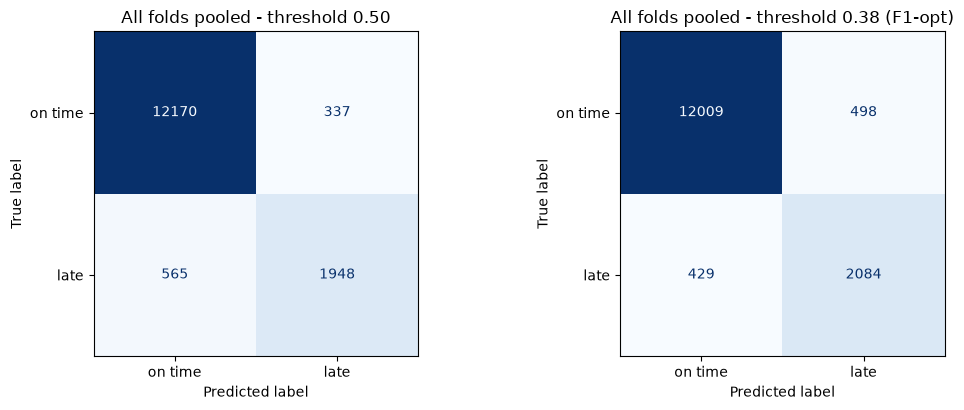

              precision    recall  f1-score   support

     on time     0.9556    0.9731    0.9643     12507
        late     0.8525    0.7752    0.8120      2513

    accuracy                         0.9399     15020
   macro avg     0.9041    0.8741    0.8881     15020
weighted avg     0.9384    0.9399    0.9388     15020



In [5]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
pooled_thr = cls[cls.rule == 'F1-opt (other folds)'].threshold.mean()
for a, thr, title in [(ax[0], 0.5, 'threshold 0.50'), (ax[1], pooled_thr, f'threshold {pooled_thr:.2f} (F1-opt)')]:
    skm.ConfusionMatrixDisplay.from_predictions(pred.y_late, (pred.p_late >= thr).astype(int), display_labels=['on time', 'late'],
                                                 cmap='Blues', values_format='d', ax=a, colorbar=False)
    a.set_title(f'All folds pooled - {title}')
plt.tight_layout(); plt.show()
print(skm.classification_report(pred.y_late, (pred.p_late >= 0.5).astype(int), target_names=['on time', 'late'], digits=4))

## 4. Curves: ROC, precision-recall, calibration, threshold trade-off

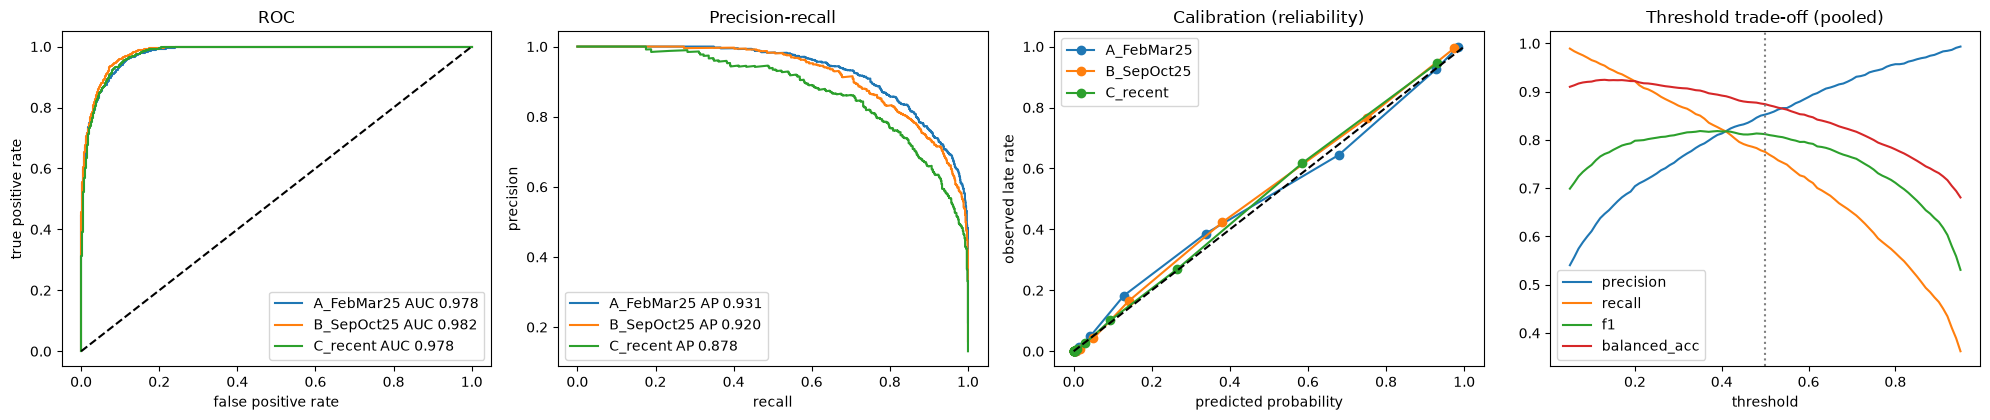

In [6]:
fig, ax = plt.subplots(1, 4, figsize=(20, 4.3))
for f, g in pred.groupby('fold'):
    fpr, tpr, _ = skm.roc_curve(g.y_late, g.p_late); ax[0].plot(fpr, tpr, label=f'{f} AUC {skm.roc_auc_score(g.y_late, g.p_late):.3f}')
    pr, rc, _ = skm.precision_recall_curve(g.y_late, g.p_late); ax[1].plot(rc, pr, label=f'{f} AP {skm.average_precision_score(g.y_late, g.p_late):.3f}')
    b = pd.qcut(g.p_late, 15, duplicates='drop'); c = g.groupby(b, observed=True)[['p_late', 'y_late']].mean()
    ax[2].plot(c.p_late, c.y_late, marker='o', label=f)
ax[0].plot([0, 1], [0, 1], 'k--'); ax[0].set(title='ROC', xlabel='false positive rate', ylabel='true positive rate'); ax[0].legend()
ax[1].set(title='Precision-recall', xlabel='recall', ylabel='precision'); ax[1].legend()
ax[2].plot([0, 1], [0, 1], 'k--'); ax[2].set(title='Calibration (reliability)', xlabel='predicted probability', ylabel='observed late rate'); ax[2].legend()
grid = np.arange(0.05, 0.96, 0.01)
sweep = pd.DataFrame([class_metrics(pred.y_late.values, pred.p_late.values, g) for g in grid])
for m in ['precision', 'recall', 'f1', 'balanced_acc']: ax[3].plot(sweep.threshold, sweep[m], label=m)
ax[3].axvline(0.5, color='grey', ls=':'); ax[3].set(title='Threshold trade-off (pooled)', xlabel='threshold'); ax[3].legend()
plt.tight_layout(); plt.show()

## 5. Lateness by segment
Does the model hold up for each brand and in monsoon conditions (the test window is 66% monsoon)?

In [7]:
def seg_metrics(g):
    y, p = g.y_late.values, g.p_late.values
    out = {'n': len(g), 'late_rate': y.mean(), 'mean_pred': p.mean(), 'brier': skm.brier_score_loss(y, p), 'log_loss': skm.log_loss(y, p, labels=[0, 1])}
    if 0 < y.mean() < 1:
        out |= {'roc_auc': skm.roc_auc_score(y, p), 'f1@0.5': skm.f1_score(y, (p >= 0.5).astype(int))}
    return pd.Series(out)
print(pred.groupby(['brand', 'monsoon']).apply(seg_metrics, include_groups=False).round(4))

                    n  late_rate  mean_pred   brier  log_loss  roc_auc  f1@0.5
brand monsoon                                                                 
Fresh 0        9827.0     0.1279     0.1251  0.0399    0.1279   0.9766  0.7644
      1        4477.0     0.2750     0.2673  0.0529    0.1670   0.9788  0.8590
Style 0         304.0     0.0296     0.0316  0.0122    0.0428   0.9917  0.6667
      1         146.0     0.0685     0.0774  0.0186    0.0603   0.9926  0.8000
Tech  0         182.0     0.0165     0.0160  0.0064    0.0251   0.9981  0.8000
      1          84.0     0.0357     0.0297  0.0100    0.0350   0.9959  0.8000


# Part B - Service time (`pred_service_min`)
## 6. Regression metrics
"Within +-k min" is the regression equivalent of accuracy: the share of deliveries whose predicted handling time is within k minutes of the actual.

In [8]:
def reg_metrics(y, p):
    e = np.abs(y - p)
    return {'MAE': e.mean(), 'RMSE': np.sqrt(np.mean((y - p) ** 2)), 'R2': skm.r2_score(y, p),
            'explained_var': skm.explained_variance_score(y, p), 'median_AE': np.median(e),
            'MAPE_%': 100 * skm.mean_absolute_percentage_error(y, p), 'max_error': e.max(), 'bias (pred-actual)': np.mean(p - y),
            'within_2min_%': 100 * (e <= 2).mean(), 'within_5min_%': 100 * (e <= 5).mean(), 'within_10min_%': 100 * (e <= 10).mean(), 'n': len(y)}
reg_tbl = pd.DataFrame({f: reg_metrics(g.y_svc.values, g.p_svc.values) for f, g in pred.groupby('fold')} |
                       {'POOLED': reg_metrics(pred.y_svc.values, pred.p_svc.values)}).T
print(reg_tbl.round(3))
print('\nby brand (pooled):'); print(pd.DataFrame({b: reg_metrics(g.y_svc.values, g.p_svc.values) for b, g in pred.groupby('brand')}).T.round(3))
allow_mae = pd.read_csv(METRICS / 'task1_baselines_service.csv').query("model == 'S1 allowance'").MAE.mean()
print(f'\nreference: dispatcher allowance MAE {allow_mae:.3f} -> model MAE {reg_tbl.drop(index="POOLED").MAE.mean():.3f}')

              MAE   RMSE     R2  explained_var  median_AE  MAPE_%  max_error  bias (pred-actual)  within_2min_%  within_5min_%  within_10min_%        n
A_FebMar25  3.591  5.438  0.806          0.808      2.507  21.388     91.355              -0.647         41.126         77.922          94.310   4851.0
B_SepOct25  3.446  5.256  0.822          0.823      2.442  20.985     87.970              -0.553         42.394         79.604          95.176   4996.0
C_recent    3.707  5.816  0.839          0.841      2.590  21.293    100.712              -0.647         40.866         76.938          93.949   5173.0
POOLED      3.583  5.513  0.825          0.827      2.507  21.221    100.712              -0.616         41.458         78.142          94.474  15020.0

by brand (pooled):
          MAE    RMSE     R2  explained_var  median_AE  MAPE_%  max_error  bias (pred-actual)  within_2min_%  within_5min_%  within_10min_%        n
Fresh   3.225   4.486  0.704          0.710      2.410  21.152     38.3

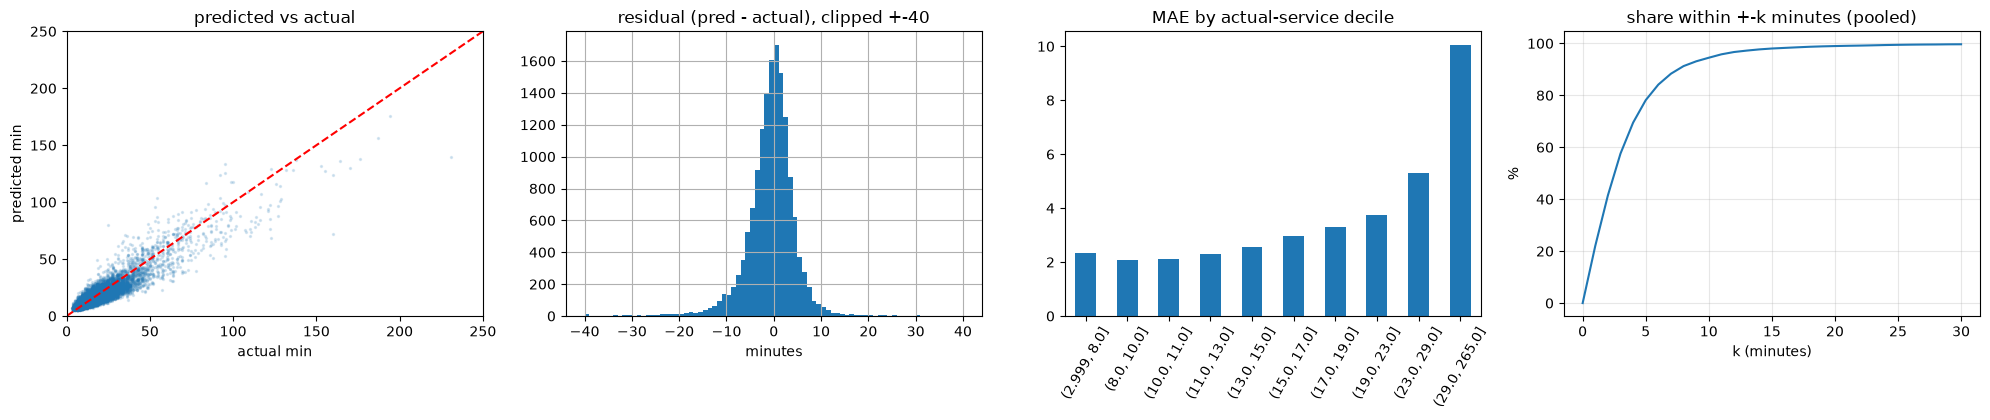

In [9]:
res = pred.p_svc - pred.y_svc
fig, ax = plt.subplots(1, 4, figsize=(20, 4.3))
ax[0].scatter(pred.y_svc, pred.p_svc, s=2, alpha=.15); ax[0].plot([0, 250], [0, 250], 'r--'); ax[0].set(xlim=(0, 250), ylim=(0, 250), title='predicted vs actual', xlabel='actual min', ylabel='predicted min')
res.clip(-40, 40).hist(bins=80, ax=ax[1]); ax[1].set(title='residual (pred - actual), clipped +-40', xlabel='minutes')
dec = pd.qcut(pred.y_svc, 10, duplicates='drop'); g = pred.assign(e=res.abs()).groupby(dec, observed=True).e.mean()
g.plot.bar(ax=ax[2]); ax[2].set(title='MAE by actual-service decile', xlabel=''); ax[2].tick_params(axis='x', rotation=60)
e = res.abs(); ks = np.arange(0, 31); ax[3].plot(ks, [100 * (e <= k).mean() for k in ks])
ax[3].set(title='share within +-k minutes (pooled)', xlabel='k (minutes)', ylabel='%'); ax[3].grid(alpha=.3)
plt.tight_layout(); plt.show()

## 7. Overfitting check: saved final model on its own training data vs validation
A large gap between in-sample and validation scores would mean overfitting. The in-sample numbers are NOT a performance estimate.

In [10]:
final_models = joblib.load(MODELS / 'task1_models.joblib')
train_X = pd.read_pickle(PROCESSED / 'task1_train_features.pkl')
t0 = time.time(); s_in, l_in = tm.predict(final_models, train_X, t['traffic']); print(f'predicted {len(train_X)} training rows in {time.time() - t0:.0f}s')
y_s, y_l = train_X.service_min.values, train_X.late.values
gap = pd.DataFrame({'in-sample (final model, train rows)': {'service MAE': np.abs(y_s - s_in).mean(), 'service RMSE': np.sqrt(np.mean((y_s - s_in) ** 2)),
                                                             'late log_loss': skm.log_loss(y_l, l_in), 'late ROC AUC': skm.roc_auc_score(y_l, l_in), 'late F1@0.5': skm.f1_score(y_l, (l_in >= 0.5).astype(int))},
                    'validation (mean of folds)': {'service MAE': reg_tbl.drop(index='POOLED').MAE.mean(), 'service RMSE': reg_tbl.drop(index='POOLED').RMSE.mean(),
                                                   'late log_loss': prob_tbl.drop(index='POOLED').log_loss.mean(), 'late ROC AUC': prob_tbl.drop(index='POOLED').roc_auc.mean(),
                                                   'late F1@0.5': cls[cls.rule == '0.50'].f1.mean()}})
print(gap.round(4))

predicted 91894 training rows in 24s
               in-sample (final model, train rows)  validation (mean of folds)
service MAE                                 3.6872                      3.5816
service RMSE                                5.5314                      5.5035
late log_loss                               0.1256                      0.1357
late ROC AUC                                0.9849                      0.9792
late F1@0.5                                 0.8552                      0.8076


## 8. Summary and save

In [11]:
summary = pd.Series({
    'late: log_loss': prob_tbl.drop(index='POOLED').log_loss.mean(), 'late: brier': prob_tbl.drop(index='POOLED').brier.mean(),
    'late: brier_skill': prob_tbl.drop(index='POOLED').brier_skill.mean(), 'late: roc_auc': prob_tbl.drop(index='POOLED').roc_auc.mean(),
    'late: pr_auc': prob_tbl.drop(index='POOLED').pr_auc.mean(), 'late: ece': prob_tbl.drop(index='POOLED').ece.mean(),
    **{f'late@0.5: {k}': cls[cls.rule == '0.50'][k].mean() for k in ['accuracy', 'precision', 'recall', 'f1', 'balanced_acc', 'mcc']},
    **{f'late@F1-opt: {k}': cls[cls.rule == 'F1-opt (other folds)'][k].mean() for k in ['threshold', 'accuracy', 'precision', 'recall', 'f1', 'balanced_acc', 'mcc']},
    **{f'service: {k}': reg_tbl.drop(index='POOLED')[k].mean() for k in ['MAE', 'RMSE', 'R2', 'median_AE', 'MAPE_%', 'within_2min_%', 'within_5min_%', 'within_10min_%']},
}, name='validation_mean_of_folds')
print(summary.round(4).to_string())
summary.to_csv(METRICS / 'task1_evaluation_summary.csv')
cls.to_csv(METRICS / 'task1_eval_classification.csv', index=False); reg_tbl.to_csv(METRICS / 'task1_eval_regression.csv')
print('\nsaved to', METRICS)

late: log_loss                0.1357
late: brier                   0.0425
late: brier_skill             0.6901
late: roc_auc                 0.9792
late: pr_auc                  0.9094
late: ece                     0.0083
late@0.5: accuracy            0.9398
late@0.5: precision           0.8519
late@0.5: recall              0.7684
late@0.5: f1                  0.8076
late@0.5: balanced_acc        0.8705
late@0.5: mcc                 0.7732
late@F1-opt: threshold        0.3833
late@F1-opt: accuracy         0.9376
late@F1-opt: precision        0.8037
late@F1-opt: recall           0.8234
late@F1-opt: f1               0.8131
late@F1-opt: balanced_acc     0.8911
late@F1-opt: mcc              0.7756
service: MAE                  3.5816
service: RMSE                 5.5035
service: R2                   0.8222
service: median_AE            2.5131
service: MAPE_%              21.2220
service: within_2min_%       41.4618
service: within_5min_%       78.1546
service: within_10min_%      94.4786

